# FigureSI_ — Demosaicing vs. direct fit, head-to-head

*Makes up Figures S7–S16.*

Compares localisation precision (`sigma_xy`) and colour precision (`sigma_colour`) for four
fitting-strategy configurations on a Bayer-filtered camera:

| Strategy | Description |
|---|---|
| `STANDARD_DATA` | Direct fit on raw Bayer data, smooth->model->raw-data-weighted refit (current production default) |
| `DEMOSAIC` (bilinear) | Demosaic the puncta ROI with bilinear interpolation, then fit each resulting R/G/B image independently |
| `DEMOSAIC` (malvar) | As above, using Malvar (2004) demosaicing |
| `DEMOSAIC` (menon2007) | As above, using Menon (2007) demosaicing |

For all three `DEMOSAIC` configurations, position (xc, yc) is the photon-weighted mean of the
three channels' fitted positions; total photons = sum of the three channels' photon counts;
per-channel colour = that channel's photon count normalised to the sum. Ground truth
positions are subtracted internally (`subtractx0y0=True`), so `sigma_xy = std(xc)` is
comparable across strategies without a shared ground-truth file.

**`FAST_MODE` flag:** `True` (default) runs ~100 bootstrap fits per condition over ~15
photon levels (log-spaced, 500-50,000) instead of the published 10,000 fits x 200 levels —
same 4 strategies x 3 dyes, so the same comparison, just noisier and coarser, in a few
minutes rather than hours. `FAST_MODE = False` reproduces the published sweep exactly.

In [1]:
import os
import time
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.spatial.distance import cdist

from pyS3M import IOFunctions, PlottingBase, sCMOSFunctions, SpectralFunctions, MaskFunctions
import pyS3M.gaussoptfuncs as gaussoptfuncs
from pyS3M.simulation.multicolour import (
    MultiC_Sim_Funcs, FittingStrategy, CameraParameters, SimulationConfig, FittingResultProcessor,
)
# Bare import (not `from src.ImageAnalysisFunctions import ...`): MultiC_Sim_Funcs bare-imports
# ImageAnalysisFunctions internally, so importing it the same way here keeps FittingStrategy
# consistent with what MSF uses. Aliased to avoid clashing with the simulation FittingStrategy above.
from pyS3M.ImageAnalysisFunctions import FittingStrategy as IAF_FittingStrategy

IO = IOFunctions.IO_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter(dark_background=False)
sCMOS = sCMOSFunctions.sCMOS_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()

REPO_ROOT = Path.cwd().resolve().parents[2]
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "Demosaicing_vs_Fullfit"     # git-ignored
FIGURE_DIR = Path("figures")                              # git-ignored (*.svg)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = True  # False -> the published 10,000-fit / 200-photon-level sweep (hours)
print(f"FAST_MODE={FAST_MODE}")
print("Available fitting strategies:", [s.value for s in FittingStrategy])

FAST_MODE=True
Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'standard_ig']


## Camera calibration and optical setup

In [2]:
gain = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
variance = IO.read_tiff(str(CALIBRATION_DIR / "variance.tif"))
readnoise = IO.read_tiff(str(CALIBRATION_DIR / "readnoise.tif"))
rqe = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])  # Bayer channel order: B, G, R

image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_parameters_dict = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": np.full((image_size, image_size), np.median(readnoise)),
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    "mosaic_unit": M_F.mosaic_unit,
}
validated_camera = CameraParameters.validate_and_create(camera_parameters_dict)

import types
smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5}, extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack, data_arg="image",
)

# Optical path filters (same as the Figure 1 dye/PSF panels).
filters = [
    "semrock-di03-r405-488-561-635-t1-25x36",  # dichroic
    "semrock-nf03-405-488-561-635e",            # notch
]
print("Camera parameters validated.")

Camera parameters validated.


## Simulation configuration

In [3]:
n_bootstrap = 100 if FAST_MODE else 10_000
n_photon_steps = 15 if FAST_MODE else 200

base_config = SimulationConfig(
    n_bootstrap=n_bootstrap, background_photons=10.0, background_colour=[1, 1, 1],
    NA=1.49, pixel_size=69, cpu_fraction=0.9, save_raw_results=True,
    subtractx0y0=True,  # ground truth subtracted before saving -- std(xc) = precision
    saverawimages=False, verbose=False, use_stochastic_photons=True, n_unit_cells=7,
)

dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
n_photon_space = np.unique(np.around(np.logspace(np.log10(500), np.log10(50000), n_photon_steps) / 5) * 5)

OUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"n_bootstrap={n_bootstrap}  n_photon_space: {len(n_photon_space)} levels, "
      f"{n_photon_space.min():.0f}-{n_photon_space.max():.0f}")
print(f"Results will be saved to: {OUT_ROOT}")

n_bootstrap=100  n_photon_space: 15 levels, 500-50000
Results will be saved to: outputs/Demosaicing_vs_Fullfit


## Example fits: direct vs. demosaic (single punctum)

Before running the full precision sweep, sanity-check both fitting strategies on one
simulated punctum: `EXAMPLE_DYE`, 1000 signal photons, 10 background photons/pixel.

- **Direct fit (`STANDARD_DATA`)**: raw / weights / fit (red X = recovered position) /
  residual / spectrum panels.
- **Demosaic fit (`DEMOSAIC`)**: demosaic the punctum into B/G/R images, fit each
  independently (red X = that channel's own recovered position), then the combined
  spectral fingerprint.

In [4]:
EXAMPLE_DYE = "ATTO 565"
EXAMPLE_N_PHOTONS = 1000.0
EXAMPLE_BACKGROUND = 10.0

avg_wl_ex, dpe_ex = S_F.get_pixel_fractions_dye_and_filters([EXAMPLE_DYE], filters, wavelength, pixel_QYs, normalized=False)
true_colour_ex = np.ravel(dpe_ex) / np.sum(dpe_ex)

x0_ex = y0_ex = image_size * 69 / 2.0
x0y0_ex = {"dye": np.array([[[x0_ex], [y0_ex]]])}
n_photons_ex = {"dye": np.array([EXAMPLE_N_PHOTONS])}

bayer_image_ex, smoothed_image_ex, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict, wavelength, avg_wl_ex, dpe_ex, n_photons_ex, x0y0_ex,
    smoothing_function=smoothing_function, background_photons=EXAMPLE_BACKGROUND,
    background_colour=[1, 1, 1], NA=1.49, pixel_size=69,
)
if bayer_image_ex.ndim == 2:
    bayer_image_ex = bayer_image_ex[np.newaxis]
    smoothed_image_ex = smoothed_image_ex[np.newaxis]

print(f"Simulated one {EXAMPLE_DYE} punctum: {EXAMPLE_N_PHOTONS:.0f} photons, {EXAMPLE_BACKGROUND:.0f} background photons/pixel")
print("True B/G/R colour fraction:", dict(zip(validated_camera.pixel_order, true_colour_ex)))

Simulated one ATTO 565 punctum: 1000 photons, 10 background photons/pixel
True B/G/R colour fraction: {'B': 0.026076003946837172, 'G': 0.39223774528002298, 'R': 0.58168625077313996}


In [5]:
example_config = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND)

pe_standard, sm_standard, _ = MSF._prepare_fitting_data(
    bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.STANDARD_DATA, example_config,
)
weights_standard, _ = MSF._compute_error_maps(sm_standard, None, validated_camera)
fit_standard = MSF._perform_fitting(
    FittingStrategy.STANDARD_DATA, pe_standard, sm_standard, weights_standard, None, validated_camera, example_config,
)

xc_std, yc_std = fit_standard["xc"].iloc[0], fit_standard["yc"].iloc[0]
s_x_std, s_y_std = fit_standard["s_x"].iloc[0], fit_standard["s_y"].iloc[0]
A_frac_std = np.array([fit_standard[f"A_{c}"].iloc[0] for c in validated_camera.pixel_order])
bg_frac_std = np.array([fit_standard[f"bg_{c}"].iloc[0] for c in validated_camera.pixel_order])
A_abs_std = A_frac_std * fit_standard["photons"].iloc[0]
bg_abs_std = bg_frac_std * fit_standard["background_photons"].iloc[0]

x_arr = np.arange(image_size, dtype=np.float32)
gauss2d_std = np.zeros((image_size, image_size), dtype=np.float32)
gauss2d_std = gaussoptfuncs.gaussian_unscaled_model(gauss2d_std, x_arr, image_size, xc_std, yc_std, s_x_std, s_y_std)

model_standard = np.zeros((image_size, image_size), dtype=np.float32)
for i, c in enumerate(validated_camera.pixel_order):
    m = validated_camera.masks[c]
    model_standard[m] = A_abs_std[i] * gauss2d_std[m] + bg_abs_std[i]

residual_standard = pe_standard[0] - model_standard

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/PlottingBase.py:487: UserWarning: Width 8.50" exceeds two-column standard (6.69")
  warnings.warn(


INFO:pyS3M.PlottingBase:Plot saved to: figures/example_fit_standard_data.svg


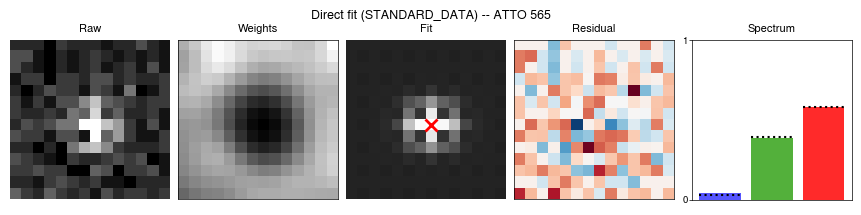

In [6]:
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]  # B, G, R

fig, axs = plotter.two_column_plot(ncols=5, width_ratios=np.ones(5), width=8.5, height=1.9)
raw_vmin, raw_vmax = np.percentile(pe_standard[0], [1, 99])

axs[0], _ = plotter.image_plot(axs[0], pe_standard[0], vmin=raw_vmin, vmax=raw_vmax, origin="upper")
axs[0].set_title("Raw", fontsize=8)

axs[1].imshow(weights_standard[0], cmap="gray", origin="upper")
axs[1].set_xticks([]); axs[1].set_yticks([])
axs[1].set_title("Weights", fontsize=8)

axs[2], _ = plotter.image_plot(axs[2], model_standard, vmin=raw_vmin, vmax=raw_vmax, origin="upper")
axs[2].plot(xc_std, yc_std, "rx", markersize=8, markeredgewidth=2)
axs[2].set_title("Fit", fontsize=8)

rmax = np.max(np.abs(residual_standard))
axs[3].imshow(residual_standard, cmap="RdBu_r", vmin=-rmax, vmax=rmax, origin="upper")
axs[3].set_xticks([]); axs[3].set_yticks([])
axs[3].set_title("Residual", fontsize=8)

axs[4].bar(np.arange(3), A_frac_std, color=channel_colours)
axs[4].hlines(true_colour_ex, xmin=np.arange(3) - 0.4, xmax=np.arange(3) + 0.4, colors="k", linestyles=":", linewidth=1.5, label="true")
axs[4].set_ylim([0, 1]); axs[4].set_xticks([]); axs[4].set_yticks([0, 1]); axs[4].grid(False)
axs[4].set_title("Spectrum", fontsize=8)

fig.suptitle(f"Direct fit (STANDARD_DATA) -- {EXAMPLE_DYE}", fontsize=9, y=1.05)
plotter.save_or_show(fig, save_path=str(FIGURE_DIR / "example_fit_standard_data.svg"), show=True)

### Demosaic fit — R/G/B images and per-channel positions

In [7]:
demosaic_example_config = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="malvar")

pe_demosaic, sm_demosaic, _ = MSF._prepare_fitting_data(
    bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.DEMOSAIC, demosaic_example_config,
)
weights_demosaic, _ = MSF._compute_error_maps(sm_demosaic, None, validated_camera)

puncta_ch = [pe_demosaic[c] for c in range(3)]
smoothed_ch = [sm_demosaic[c] for c in range(3)]
weights_ch = [weights_demosaic[c] for c in range(3)]
coords_ch = [(0, 0)] * 3
planes_ch = [0, 1, 2]

raw_channel_fits, _ = MSF.image_analysis.fit_puncta_parallel_method(
    puncta_ch, smoothed_ch, weights_ch, coords_ch, planes_ch, IAF_FittingStrategy.NOCOLOUR,
)
raw_channel_fits = pd.DataFrame(
    raw_channel_fits, columns=["xc", "yc", "s_x", "s_y", "b", "A", "chi_sqr", "frame"]
).sort_values(by="frame").reset_index(drop=True)

combined_demosaic = FittingResultProcessor.fit_averager(raw_channel_fits, n_bootstrap=1)
spectrum_demosaic = np.array([combined_demosaic[f"A_{c}"].iloc[0] for c in validated_camera.pixel_order])

model_channel_fits = []
for row in raw_channel_fits.itertuples():
    gauss2d_ch = np.zeros((image_size, image_size), dtype=np.float32)
    gauss2d_ch = gaussoptfuncs.gaussian_unscaled_model(gauss2d_ch, x_arr, image_size, row.xc, row.yc, row.s_x, row.s_y)
    model_channel_fits.append(row.A * gauss2d_ch + row.b)

for c, row in zip(validated_camera.pixel_order, raw_channel_fits.itertuples()):
    print(f"{c}: xc={row.xc:.2f} yc={row.yc:.2f} A={row.A:.1f} chi_sqr={row.chi_sqr:.2f}")
print(f"Combined position (photon-weighted): xc={combined_demosaic['xc'].iloc[0]:.2f} yc={combined_demosaic['yc'].iloc[0]:.2f}")
print("Combined spectrum:", dict(zip(validated_camera.pixel_order, spectrum_demosaic)))

B: xc=6.97 yc=7.03 A=86.1 chi_sqr=0.93
G: xc=7.14 yc=6.94 A=402.8 chi_sqr=0.77
R: xc=7.03 yc=6.98 A=546.8 chi_sqr=0.96
Combined position (photon-weighted): xc=7.07 yc=6.97
Combined spectrum: {'B': 0.083104938268661499, 'G': 0.38891980051994324, 'R': 0.52797526121139526}


INFO:pyS3M.PlottingBase:Plot saved to: figures/example_fit_demosaic_malvar.svg


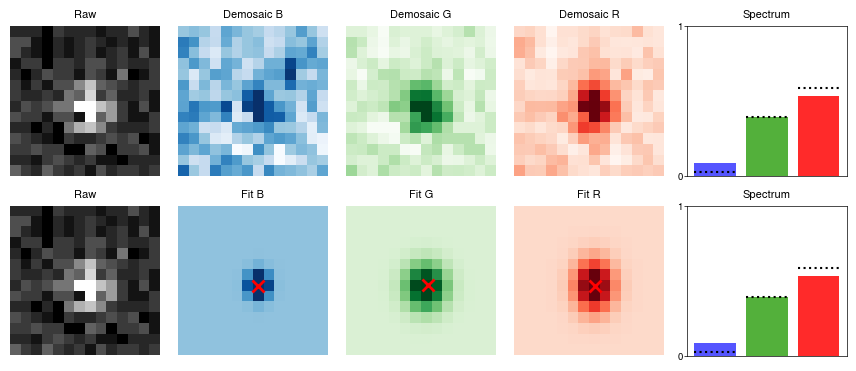

In [8]:
fig2, axs2 = plotter.two_column_plot(nrows=2, ncols=5, width_ratios=np.ones(5), height_ratios=[1, 1], width=8.5, height=3.6)
raw_vmin_d, raw_vmax_d = np.percentile(pe_standard[0], [1, 99])

for row in (0, 1):
    axs2[row, 0], _ = plotter.image_plot(axs2[row, 0], pe_standard[0], vmin=raw_vmin_d, vmax=raw_vmax_d, origin="upper")
axs2[0, 0].set_title("Raw", fontsize=8)
axs2[1, 0].set_title("Raw", fontsize=8)

cmaps = ["Blues", "Greens", "Reds"]
for i, c in enumerate(validated_camera.pixel_order):
    vmin_c, vmax_c = np.percentile(pe_demosaic[i], [1, 99])
    axs2[0, i + 1], _ = plotter.image_plot(axs2[0, i + 1], pe_demosaic[i], vmin=vmin_c, vmax=vmax_c, origin="upper", cmap=cmaps[i])
    axs2[0, i + 1].set_title(f"Demosaic {c}", fontsize=8)
    axs2[1, i + 1], _ = plotter.image_plot(axs2[1, i + 1], model_channel_fits[i], vmin=vmin_c, vmax=vmax_c, origin="upper", cmap=cmaps[i])
    axs2[1, i + 1].plot(raw_channel_fits["xc"].iloc[i], raw_channel_fits["yc"].iloc[i], "rx", markersize=8, markeredgewidth=2)
    axs2[1, i + 1].set_title(f"Fit {c}", fontsize=8)

for row in (0, 1):
    axs2[row, 4].bar(np.arange(3), spectrum_demosaic, color=channel_colours)
    axs2[row, 4].hlines(true_colour_ex, xmin=np.arange(3) - 0.4, xmax=np.arange(3) + 0.4, colors="k", linestyles=":", linewidth=1.5, label="true")
    axs2[row, 4].set_ylim([0, 1]); axs2[row, 4].set_xticks([]); axs2[row, 4].set_yticks([0, 1]); axs2[row, 4].grid(False)
    axs2[row, 4].set_title("Spectrum", fontsize=8)

plotter.save_or_show(fig2, save_path=str(FIGURE_DIR / "example_fit_demosaic_malvar.svg"), show=True)

### Timing: direct fit vs. demosaic fit (single punctum)

Wall-clock cost of fitting the one punctum above, direct (`STANDARD_DATA`) vs. demosaic.
Uses the serial `fit_puncta_method` (not the parallel wrapper, which spins up a fresh
`ProcessPoolExecutor` on every call and would swamp the actual per-punctum cost).

In [9]:
masks_3d = np.dstack([validated_camera.masks[c] for c in validated_camera.pixel_order])
MSF.image_analysis.processors[IAF_FittingStrategy.STANDARD_DATA].readnoise = float(np.median(validated_camera.readnoise))


def time_standard_once():
    t0 = time.perf_counter()
    pe_s, sm_s, _ = MSF._prepare_fitting_data(bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.STANDARD_DATA, example_config)
    w_s, _ = MSF._compute_error_maps(sm_s, None, validated_camera)
    MSF.image_analysis.fit_puncta_method([pe_s[0]], [sm_s[0]], [w_s[0]], [(0, 0)], [0], IAF_FittingStrategy.STANDARD_DATA, masks=[masks_3d])
    return time.perf_counter() - t0


def time_demosaic_once(demosaic_config):
    t0 = time.perf_counter()
    pe_d, sm_d, _ = MSF._prepare_fitting_data(bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.DEMOSAIC, demosaic_config)
    w_d, _ = MSF._compute_error_maps(sm_d, None, validated_camera)
    fits, _ = MSF.image_analysis.fit_puncta_method(
        [pe_d[c] for c in range(3)], [sm_d[c] for c in range(3)], [w_d[c] for c in range(3)],
        [(0, 0)] * 3, [0, 1, 2], IAF_FittingStrategy.NOCOLOUR,
    )
    fits_df = pd.DataFrame(fits, columns=["xc", "yc", "s_x", "s_y", "b", "A", "chi_sqr", "frame"]).sort_values(by="frame").reset_index(drop=True)
    FittingResultProcessor.fit_averager(fits_df, n_bootstrap=1)
    return time.perf_counter() - t0


demosaic_config_bilinear = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="bilinear")
demosaic_config_malvar = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="malvar")
demosaic_config_menon = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="menon2007")

# Warm-up (numba JIT compilation etc.) -- excluded from the timed measurements.
time_standard_once()
time_demosaic_once(demosaic_config_bilinear)
time_demosaic_once(demosaic_config_malvar)
time_demosaic_once(demosaic_config_menon)

N_TIMING_REPEATS = 300 if FAST_MODE else 10_000
standard_times = np.array([time_standard_once() for _ in range(N_TIMING_REPEATS)])
demosaic_times_bilinear = np.array([time_demosaic_once(demosaic_config_bilinear) for _ in range(N_TIMING_REPEATS)])
demosaic_times_malvar = np.array([time_demosaic_once(demosaic_config_malvar) for _ in range(N_TIMING_REPEATS)])
demosaic_times_menon = np.array([time_demosaic_once(demosaic_config_menon) for _ in range(N_TIMING_REPEATS)])

print(f"STANDARD_DATA (direct fit), N={N_TIMING_REPEATS}: {standard_times.mean()*1000:.3f} +/- {standard_times.std()*1000:.3f} ms")
print(f"BILINEAR DEMOSAIC, N={N_TIMING_REPEATS}: {demosaic_times_bilinear.mean()*1000:.3f} +/- {demosaic_times_bilinear.std()*1000:.3f} ms")
print(f"MALVAR DEMOSAIC, N={N_TIMING_REPEATS}: {demosaic_times_malvar.mean()*1000:.3f} +/- {demosaic_times_malvar.std()*1000:.3f} ms")
print(f"MENON DEMOSAIC, N={N_TIMING_REPEATS}: {demosaic_times_menon.mean()*1000:.3f} +/- {demosaic_times_menon.std()*1000:.3f} ms")

STANDARD_DATA (direct fit), N=300: 0.502 +/- 0.016 ms
BILINEAR DEMOSAIC, N=300: 1.365 +/- 0.099 ms
MALVAR DEMOSAIC, N=300: 1.495 +/- 0.155 ms
MENON DEMOSAIC, N=300: 2.206 +/- 0.016 ms


INFO:pyS3M.PlottingBase:Plot saved to: figures/example_fit_timing.svg


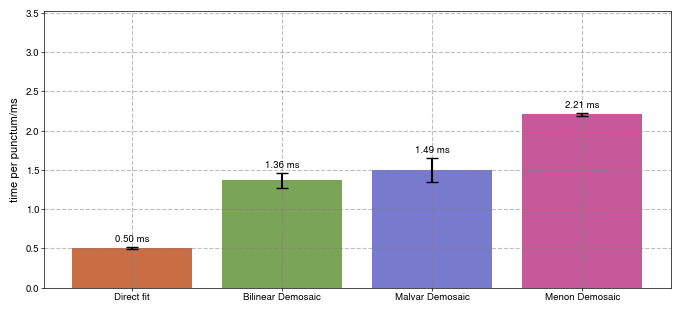

In [10]:
fig3, ax3 = plotter.two_column_plot(ncols=1)

timing_labels = ["Direct fit", "Bilinear Demosaic", "Malvar Demosaic", "Menon Demosaic"]
timing_means_ms = [standard_times.mean() * 1000, demosaic_times_bilinear.mean() * 1000, demosaic_times_malvar.mean() * 1000, demosaic_times_menon.mean() * 1000]
timing_stds_ms = [standard_times.std() * 1000, demosaic_times_bilinear.std() * 1000, demosaic_times_malvar.std() * 1000, demosaic_times_menon.std() * 1000]
ax3.bar(timing_labels, timing_means_ms, yerr=timing_stds_ms, capsize=4, color=["#c96d44", "#7aa456", "#777acd", "#c65999"])
ax3.set_ylabel("time per punctum/ms")
ax3.grid(True, ls="--", alpha=0.5, color="gray")

for i, (mean_ms, std_ms) in enumerate(zip(timing_means_ms, timing_stds_ms)):
    ax3.text(i, mean_ms + std_ms + 0.02 * max(timing_means_ms), f"{mean_ms:.2f} ms", ha="center", va="bottom", fontsize=7)

ax3.set_ylim([0, max(timing_means_ms) * 1.6])
plotter.save_or_show(fig3, save_path=str(FIGURE_DIR / "example_fit_timing.svg"), show=True)

## Run simulations

Four strategy configurations x three dyes. Each configuration uses a distinct
`starting_flag` so files do not collide. `overwrite=False` so an interrupted run can resume.

In [11]:
runs = [
    (FittingStrategy.STANDARD_DATA, "standard_data_", base_config),
    (FittingStrategy.DEMOSAIC, "demosaic_bilinear_", replace(base_config, demosaic_strategy="bilinear")),
    (FittingStrategy.DEMOSAIC, "demosaic_malvar_", replace(base_config, demosaic_strategy="malvar")),
    (FittingStrategy.DEMOSAIC, "demosaic_menon2007_", replace(base_config, demosaic_strategy="menon2007")),
]

camera_params_dict = validated_camera.__dict__.copy()

for strategy, flag, cfg in runs:
    for dye in dyes:
        label = f"{strategy.value} [{cfg.demosaic_strategy}]" if strategy == FittingStrategy.DEMOSAIC else strategy.value
        print(f"Running {label} / {dye} ...")
        try:
            MSF.test_simulation_method(
                dye=dye, filters=filters, wavelength=wavelength, camera_parameters=camera_params_dict,
                save_folder=str(OUT_ROOT), n_photon_space=n_photon_space, smoothing_function=smoothing_function,
                strategy=strategy, starting_flag=flag, config=cfg, overwrite=False,
            )
            print(f"  Done: {label} / {dye}")
        except Exception as e:
            print(f"  FAILED {label} / {dye}: {e}")

print("All simulations complete.")

Running standard_data / ATTO 488 ...


INFO:pyS3M.simulation.multicolour:
Completed analysis of 15 photon flux values    Total time: 0.086 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


  Done: standard_data / ATTO 488
Running standard_data / ATTO 565 ...


INFO:pyS3M.simulation.multicolour:
Completed analysis of 15 photon flux values    Total time: 0.088 min


...

INFO:pyS3M.simulation.multicolour:Simulation completed for strategy demosaic


  Done: demosaic [menon2007] / ATTO 565
Running demosaic [menon2007] / ATTO 647N ...


INFO:pyS3M.simulation.multicolour:
Completed analysis of 15 photon flux values    Total time: 0.116 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy demosaic


  Done: demosaic [menon2007] / ATTO 647N
All simulations complete.


## Load results and compute precision metrics

Because `subtractx0y0=True`, the saved `xc`/`yc` columns are already *(fitted - truth)*, so:

`sigma_xy = sqrt((std(xc)^2 + std(yc)^2) / 2) * 69 nm`

Colour precision is the standard deviation of the Euclidean distance from each fitted
`(A_B, A_G, A_R)` point to the true colour vector.

In [12]:
strategy_labels = ["Direct fit (STANDARD_DATA)", "Demosaic (bilinear)", "Demosaic (malvar)", "Demosaic (menon2007)"]
strategy_flags = ["standard_data_", "demosaic_bilinear_", "demosaic_malvar_", "demosaic_menon2007_"]
parameters = ["xy", "colour", "B", "G", "R", "chi_mean", "chi_median", "chi_std"]

all_files = os.listdir(OUT_ROOT)

Overall_XR = xr.DataArray(
    data=np.full([len(strategy_labels), len(dyes), len(n_photon_space), len(parameters)], np.nan),
    coords=[strategy_labels, dyes, n_photon_space, parameters],
    dims=["Strategy", "Dye", "Photon", "Metric"],
)

for i, (label, flag) in enumerate(zip(strategy_labels, strategy_flags)):
    prefix = flag + "LM_method"
    flag_files = [x for x in all_files if x.startswith(prefix)]
    for j, dye in enumerate(dyes):
        dyestr = dye.replace("/", "-")
        raw_files = [os.path.join(OUT_ROOT, x) for x in flag_files if dyestr in x and "rawresults" in x]
        param_files = [os.path.join(OUT_ROOT, x) for x in flag_files if dyestr in x and "input_parameters" in x]
        if not raw_files or not param_files:
            print(f"Missing files for {label} / {dye} -- skipping.")
            continue

        true_bgr = pd.read_csv(param_files[0]).to_numpy()[0][-3:]
        true_bgr = true_bgr / np.sum(true_bgr)
        true_colour = np.expand_dims(true_bgr, 0)

        results_all = pd.read_hdf(raw_files[0])

        for k, photonval in enumerate(n_photon_space):
            results = results_all[results_all["photon_level"] == k]
            if len(results) == 0:
                continue

            filt = ~((results["s_x"] < 0) | (results["s_y"] < 0))
            xc = results["xc"].to_numpy()[filt]
            yc = results["yc"].to_numpy()[filt]
            chi_sqr = results["chi_sqr"].to_numpy()[filt]

            sigma_xy = np.sqrt((np.nanstd(xc) ** 2 + np.nanstd(yc) ** 2) / 2) * 69

            colour = np.vstack([results["A_B"].to_numpy()[filt], results["A_G"].to_numpy()[filt], results["A_R"].to_numpy()[filt]]).T
            colour_dist = cdist(colour, true_colour).ravel()
            B_dist = np.sqrt(np.square(colour[:, 0] - true_colour[:, 0]))
            G_dist = np.sqrt(np.square(colour[:, 1] - true_colour[:, 1]))
            R_dist = np.sqrt(np.square(colour[:, 2] - true_colour[:, 2]))

            Overall_XR[i, j, k, 0] = sigma_xy
            Overall_XR[i, j, k, 1] = np.nanstd(colour_dist)
            Overall_XR[i, j, k, 2] = np.nanstd(B_dist)
            Overall_XR[i, j, k, 3] = np.nanstd(G_dist)
            Overall_XR[i, j, k, 4] = np.nanstd(R_dist)
            Overall_XR[i, j, k, 5] = np.nanmean(chi_sqr)
            Overall_XR[i, j, k, 6] = np.nanmedian(chi_sqr)
            Overall_XR[i, j, k, 7] = np.nanstd(chi_sqr)

print("Results loaded.")
Overall_XR.to_netcdf(OUT_ROOT / "Demosaic_vs_DirectFit_STDEV.nc")
print("Saved to Demosaic_vs_DirectFit_STDEV.nc")

Results loaded.
Saved to Demosaic_vs_DirectFit_STDEV.nc


## Plot — dye-averaged precision vs photon count

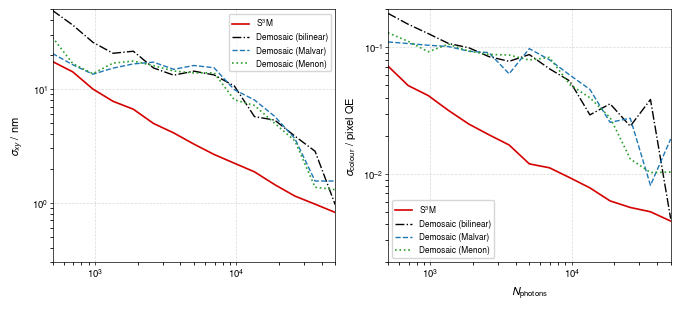

In [13]:
plot_styles = [
    {"color": "#d40000", "linestyle": "-", "linewidth": 1.2},   # Direct fit
    {"color": "black", "linestyle": "-.", "linewidth": 1.0},    # Demosaic (bilinear)
    {"color": "#1f77b4", "linestyle": "--", "linewidth": 1.0},  # Demosaic (malvar)
    {"color": "#2ca02c", "linestyle": ":", "linewidth": 1.2},   # Demosaic (menon2007)
]
plot_labels = ["S$^3$M", "Demosaic (bilinear)", "Demosaic (Malvar)", "Demosaic (Menon)"]

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=np.ones(2))

for i, (label, style) in enumerate(zip(plot_labels, plot_styles)):
    mean_xy = np.nanmean(Overall_XR[i, :, :, 0], axis=0)
    mean_colour = np.nanmean(Overall_XR[i, :, :, 1], axis=0)
    axs[0] = plotter.line_plot(axs[0], n_photon_space, mean_xy, label=label, xlabel=r"$N_{\mathrm{photons}}$", ylabel=r"$\sigma_{xy}$ / nm", **style)
    axs[1] = plotter.line_plot(axs[1], n_photon_space, mean_colour, label=label, xlabel=r"$N_{\mathrm{photons}}$", ylabel=r"$\sigma_{\mathrm{colour}}$ / pixel QE", **style)

for ax in axs:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim([500, 50000])

axs[0].set_ylim([0.3, 50])
axs[0].set_xlabel("")
axs[1].set_ylim([2e-3, 0.2])
axs[0].legend(loc="best", fontsize=6)

plt.savefig(FIGURE_DIR / "Demosaic_vs_DirectFit.svg", dpi=600, format="svg")
plt.show()

## Plot — per-dye precision vs photon count (one row per dye)

Same as the dye-averaged plot above, but one row per dye instead of averaging over them —
lets strategy differences that are dye-dependent show up directly.

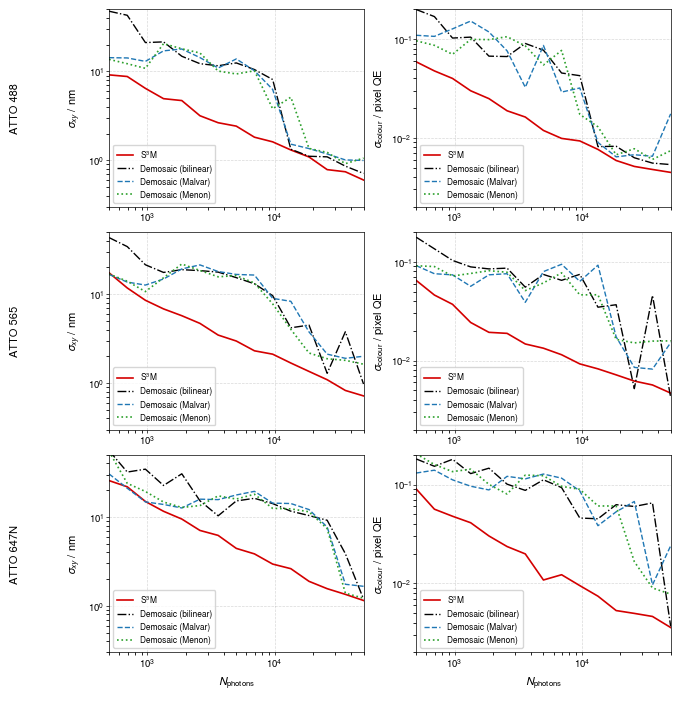

In [14]:
fig, axs = plotter.two_column_plot(nrows=len(dyes), ncols=2, width_ratios=[1, 1], height_ratios=[1] * len(dyes), width=6.69, height=2.3 * len(dyes))

for row, dye in enumerate(dyes):
    for i, (label, style) in enumerate(zip(plot_labels, plot_styles)):
        xy_vals = Overall_XR[i, row, :, 0]
        colour_vals = Overall_XR[i, row, :, 1]
        axs[row, 0] = plotter.line_plot(axs[row, 0], n_photon_space, xy_vals, label=label, xlabel=r"$N_{\mathrm{photons}}$", ylabel=r"$\sigma_{xy}$ / nm", **style)
        axs[row, 1] = plotter.line_plot(axs[row, 1], n_photon_space, colour_vals, label=label, xlabel=r"$N_{\mathrm{photons}}$", ylabel=r"$\sigma_{\mathrm{colour}}$ / pixel QE", **style)

    axs[row, 0].set_xscale("log"); axs[row, 0].set_yscale("log")
    axs[row, 1].set_xscale("log"); axs[row, 1].set_yscale("log")
    axs[row, 0].set_xlim([500, 50000]); axs[row, 1].set_xlim([500, 50000])
    axs[row, 0].set_ylim([0.3, 50]); axs[row, 1].set_ylim([2e-3, 0.2])
    if row < len(dyes) - 1:
        axs[row, 0].set_xlabel(""); axs[row, 1].set_xlabel("")
    axs[row, 0].text(-0.35, 0.5, dye, transform=axs[row, 0].transAxes, fontsize=8, ha="right", va="center", rotation=90)

axs[0, 0].legend(loc="best", fontsize=6)
plt.savefig(FIGURE_DIR / "Demosaic_vs_DirectFit_per_dye.svg", dpi=600, format="svg")
plt.show()

## Plot — fit-distribution histograms across strategies

One figure per dye, rows = quantity (position bias x/y overlaid; colour fraction B/G/R
overlaid), columns = fitting strategy. `HISTOGRAM_PHOTON_LEVELS` overlays a few photon
counts per panel (colour still encodes the series; linestyle distinguishes photon level).

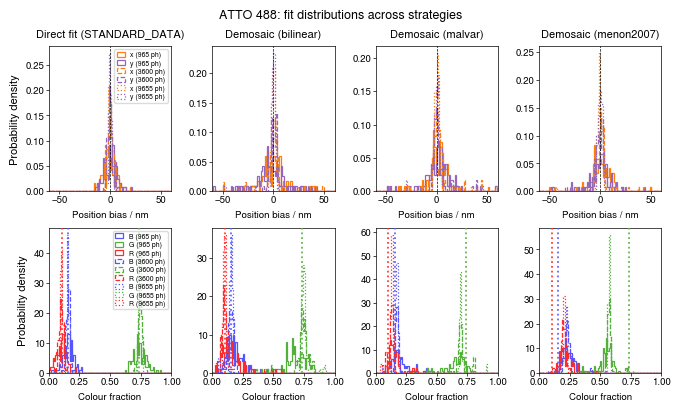

Saved: ATTO_488_strategy_histograms.svg


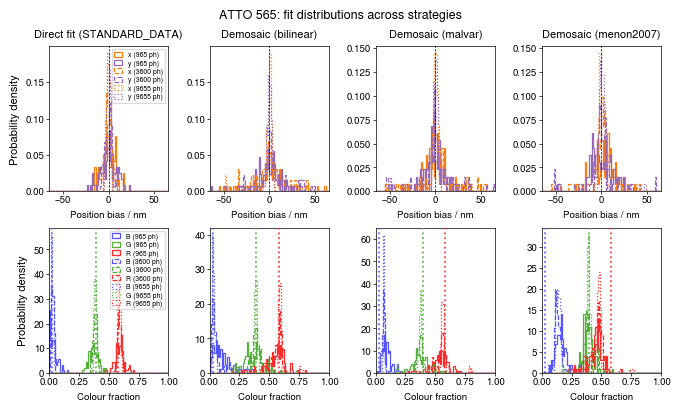

Saved: ATTO_565_strategy_histograms.svg


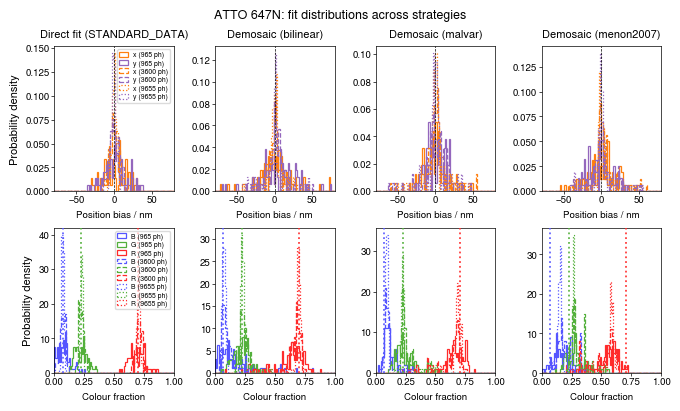

Saved: ATTO_647N_strategy_histograms.svg


In [15]:
HISTOGRAM_PHOTON_LEVELS = [1000.0, 4000.0, 10000.0]
photon_linestyles = ["-", "--", ":", "-."][:len(HISTOGRAM_PHOTON_LEVELS)]
photon_idx = [int(np.argmin(np.abs(n_photon_space - p))) for p in HISTOGRAM_PHOTON_LEVELS]
photon_actual = [n_photon_space[k] for k in photon_idx]

pos_colors = ["tab:orange", "tab:purple"]
col_labels = ["B", "G", "R"]
col_names = ["A_B", "A_G", "A_R"]
hist_bins = 100 if FAST_MODE else 200
col_xlim = (0.0, 1.0)

for dye in dyes:
    dyestr = dye.replace("/", "-")

    raw_by_strategy = []
    for label, flag in zip(strategy_labels, strategy_flags):
        prefix = flag + "LM_method"
        flag_files = [x for x in all_files if x.startswith(prefix)]
        raw_files = [os.path.join(OUT_ROOT, x) for x in flag_files if dyestr in x and "rawresults" in x]
        raw_by_strategy.append(pd.read_hdf(raw_files[0]) if raw_files else None)

    true_colour_dye = None
    for flag in strategy_flags:
        prefix = flag + "LM_method"
        flag_files = [x for x in all_files if x.startswith(prefix)]
        param_files = [os.path.join(OUT_ROOT, x) for x in flag_files if dyestr in x and "input_parameters" in x]
        if param_files:
            true_bgr_dye = pd.read_csv(param_files[0]).to_numpy()[0][-3:]
            true_colour_dye = true_bgr_dye / np.sum(true_bgr_dye)
            break

    pos_concat = []
    for df in raw_by_strategy:
        if df is None:
            continue
        for k in photon_idx:
            sub = df[df["photon_level"] == k]
            pos_concat.append(sub["xc"].to_numpy() * 69)
            pos_concat.append(sub["yc"].to_numpy() * 69)
    pos_concat = np.concatenate(pos_concat) if pos_concat else np.array([0.0])
    pos_concat = pos_concat[np.isfinite(pos_concat)]
    pos_lim = float(np.nanpercentile(np.abs(pos_concat), 99.5)) * 1.2 if len(pos_concat) else 50.0
    pos_xlim = (-pos_lim, pos_lim)

    fig, axs = plotter.two_column_plot(nrows=2, ncols=len(strategy_labels), height=4)

    for col, (label, df) in enumerate(zip(strategy_labels, raw_by_strategy)):
        ax_pos, ax_col = axs[0, col], axs[1, col]
        ax_pos.set_title(label, fontsize=8)

        if df is None:
            ax_pos.axis("off"); ax_col.axis("off")
            continue

        for ls, k, photon_val in zip(photon_linestyles, photon_idx, photon_actual):
            sub = df[df["photon_level"] == k]
            xvals = sub["xc"].to_numpy()[np.isfinite(sub["xc"].to_numpy())] * 69
            yvals = sub["yc"].to_numpy()[np.isfinite(sub["yc"].to_numpy())] * 69
            ax_pos.hist(xvals, bins=hist_bins, range=pos_xlim, density=True, histtype="step",
                        color=pos_colors[0], linestyle=ls, linewidth=0.9, label=f"x ({photon_val:.0f} ph)" if col == 0 else None)
            ax_pos.hist(yvals, bins=hist_bins, range=pos_xlim, density=True, histtype="step",
                        color=pos_colors[1], linestyle=ls, linewidth=0.9, label=f"y ({photon_val:.0f} ph)" if col == 0 else None)

            for cc, cl, cname in zip(channel_colours, col_labels, col_names):
                cvals = sub[cname].to_numpy()
                cvals = cvals[np.isfinite(cvals)]
                ax_col.hist(cvals, bins=hist_bins, range=col_xlim, density=True, histtype="step",
                            color=cc, linestyle=ls, linewidth=0.9, label=f"{cl} ({photon_val:.0f} ph)" if col == 0 else None)

        ax_pos.axvline(0, color="k", linewidth=0.5, linestyle="--")
        if true_colour_dye is not None:
            for cc, tv in zip(channel_colours, true_colour_dye):
                ax_col.axvline(tv, color=cc, linewidth=1.3, linestyle=":", alpha=0.9, zorder=5)

        ax_pos.set_xlim(pos_xlim)
        ax_col.set_xlim(col_xlim)
        ax_col.set_xlabel("Colour fraction", fontsize=7)
        ax_pos.set_xlabel("Position bias / nm", fontsize=7)

        if col == 0:
            ax_pos.set_ylabel("Probability density", fontsize=8)
            ax_col.set_ylabel("Probability density", fontsize=8)
            ax_pos.legend(fontsize=5, loc="upper right", framealpha=0.7, handlelength=1.2, borderpad=0.3, labelspacing=0.2)
            ax_col.legend(fontsize=5, loc="upper right", framealpha=0.7, handlelength=1.2, borderpad=0.3, labelspacing=0.2)
        else:
            ax_pos.set_ylabel(""); ax_col.set_ylabel("")

    fig.suptitle(f"{dye}: fit distributions across strategies", fontsize=9)
    fname = f"{dye.replace(' ', '_')}_strategy_histograms.svg"
    fig.savefig(FIGURE_DIR / fname, dpi=600, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Next steps

Set `FAST_MODE = False` above and re-run for the published sweep (10,000 bootstrap fits x
200 photon levels x 4 strategies x 3 dyes — expect hours, and a large
`outputs/Demosaicing_vs_Fullfit/` directory of intermediate HDF5/CSV files, git-ignored).